In [18]:
import os
import pandas as pd

In [19]:
data_sources = ['facebook-data_.csv',
                'twitter-data_.csv',
                'gnews_operation_sindoor_headlines.csv',
                'gnews_pahalgam_attack_headlines.csv',
                'media_stack_operation_sindoor_headlines.csv',
                'media_stack_pahalgam_attack_headlines.csv',
                'news_api_operation_sindoor_headlines.csv',
                'news_api_pahalgam_attack_headlines.csv',
                'google_news_pahalgam_attack_headlines.csv',
                'google_news_operation_sindoor_headlines.csv',
                ]

In [20]:
def extract_publishers(df, col_name):
    return set(df[col_name].dropna().unique())

In [21]:
publisher_sets = []
for data_source in data_sources:
    df = pd.read_csv(f"../outputs/{data_source}")
    #print(df.columns)
    if 'author' in df.columns:
        #print(f'author was found  in {data_source}')
        publisher_sets.append(extract_publishers(df, 'author'))
    elif 'source_name' in df.columns:
        #print(f'source_name was found  in {data_source}')
        publisher_sets.append(extract_publishers(df, 'source_name'))
    elif 'source' in df.columns:
        #print(f'source was found  in {data_source}')
        publisher_sets.append(extract_publishers(df, 'source'))

print(f"All publishers: \n{publisher_sets}")

common_publishers = set.intersection(*publisher_sets)
print(f"Common Publishers/Handles Across All Datasets:\n{common_publishers}")

All publishers: 
[{'The Times of India', 'SkyNews', 'PTI News', 'FirstPost', 'ANI News', 'Economic Times', 'the hindu'}, {'FirstPost', 'Sky News', 'The Hindu', 'ANI', 'timesofindia', 'PTI', 'EconomicTimes'}, set(), set(), {'Binoy Kampmark', 'DC Web Desk', 'Deccan Chronicle', 'Sampat G. Samritan', 'zee business', 'India Post Newspaper', 'DC Correspondent', 'Aman Wadhwa', 'Apurwa Amit', 'Amresh Srivastava', 'ANI', 'DC Editorial', 'NDTV Profit News', 'a guest author', 'shashi bhushan', 'PTI', 'Shreya Sur', 'Simran Singh', 'Pramode Mallik', 'Anita Anand', 'NDTV Profit Desk', 'Bhagwan Parab', 'Dr S Jatin Kumar', 'Manoj Anand', 'News desk', 'pawan bali', 'Syed Ata Hasnain', 'Falaknaaz Syed', 'Yusuf Jameel', 'No Author', 'Divya Prata'}, {'Onam Gupta', 'Nivedita Dash', 'Anirudha Yerunkar', 'Sumaila Zaman'}, {'TK Arun', 'Jatin Takkar', 'ET Online', 'Sameer Bhardwaj', 'TNN', 'Akhilesh Kumar Singh', 'Navdeep Singh', 'Gaurav Gupta', 'ET CONTRIBUTORS', 'Maulik Vyas', 'ANI', 'PTI', 'Nikhil Agarwal',

In [22]:
import re
from difflib import get_close_matches

# Step 1: Flatten all publisher sets
all_publishers = set().union(*publisher_sets)

# Step 2: Normalize function
def normalize(name):
    name = name.lower()
    name = re.sub(r'[^a-z0-9]', '', name)  # remove non-alphanumerics
    return name

# Step 3: Create a mapping of normalized -> original
normalized_to_originals = {}
for name in all_publishers:
    norm = normalize(name)
    normalized_to_originals.setdefault(norm, set()).add(name)

# Step 4: Group similar normalized names
canonical_groups = {}
visited = set()

for norm_name in normalized_to_originals:
    if norm_name in visited:
        continue
    group = set()
    matches = get_close_matches(norm_name, normalized_to_originals.keys(), cutoff=0.8)
    for match in matches:
        group.update(normalized_to_originals[match])
        visited.add(match)
    canonical_name = sorted(group)[0]  # pick one as canonical (e.g., alphabetically first)
    canonical_groups[canonical_name] = group

# Step 5: Display results
for canonical, variants in canonical_groups.items():
    print(f"{canonical}: {sorted(variants)}")


Binoy Kampmark: ['Binoy Kampmark']
FirstPost: ['FirstPost']
Onam Gupta: ['Onam Gupta']
ET Online: ['ET Online']
Akhilesh Kumar Singh: ['Akhilesh Kumar Singh', 'Akhilesh Singh']
Navdeep Singh: ['Navdeep Singh']
India Post Newspaper: ['India Post Newspaper']
DC Correspondent: ['DC Correspondent']
Apurwa Amit: ['Apurwa Amit']
Maulik Vyas: ['Maulik Vyas']
Sky News: ['Sky News', 'SkyNews']
Amresh Srivastava: ['Amresh Srivastava']
NDTV Profit Desk: ['NDTV Profit Desk', 'NDTV Profit News']
Press Trust of India: ['Press Trust of India']
a guest author: ['a guest author']
Shreya Sur: ['Shreya Sur']
PTI News: ['PTI News']
Nadim Asrar: ['Nadim Asrar']
Sanjay Khajuria: ['Sanjay Khajuria']
Dipak K Dash: ['Dipak K Dash']
Bhagwan Parab: ['Bhagwan Parab']
DP Bhattacharya: ['DP Bhattacharya']
Ritu Dutta: ['Ritu Dutta']
Dr S Jatin Kumar: ['Dr S Jatin Kumar']
The Times of India: ['The Times of India', 'timesofindia']
Manoj Anand: ['Manoj Anand']
Amir Daftari: ['Amir Daftari']
pawan bali: ['pawan bali']
F

In [23]:
common_publisher_mappings = {
    "economic_times": ['ET CONTRIBUTORS', 'Economic Times', 'EconomicTimes', 'ET Bureau', 'ETtech', 'ET Online'],
    "pti": ['PTI', 'PTI News', 'Press Trust of India'],
    "the_hindu": ['The Hindu', 'the hindu'],
    "the_times_of_india": ['The Times of India', 'timesofindia'],
    "google_news": ['GoogleNews'],
    "sky_news": ['Sky News', 'SkyNews'],
    "first_post": ['FirstPost'],
    "ani_news": ['ANI', 'ANI News']
}


In [24]:
dataframes = {}
for data_source in data_sources:
    df = pd.read_csv(f"../outputs/{data_source}")
    dataframes.update({data_source: df})

In [25]:
alias_to_canonical = {
    alias: canonical
    for canonical, aliases in common_publisher_mappings.items()
    for alias in aliases
}


In [26]:
source_columns = ['source', 'source_name', 'author']
updated_dataframes = {}

In [27]:
for name, df in dataframes.items():
    df_copy = df.copy()
    for col in source_columns:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].replace(alias_to_canonical)
    updated_dataframes[name] = df_copy

In [28]:
unified_records = []

In [29]:
# Facebook
if "facebook-data_.csv" in updated_dataframes:
    fb = updated_dataframes["facebook-data_.csv"]
    fb_records = fb[["author", "timestamp", "message", "country", "sentiment", "likes", "comments"]].copy()
    fb_records["engagement"] = fb_records["likes"] + fb_records["comments"]
    fb_records.rename(columns={"timestamp": "date", "message": "headlines", "sentiment": "sentiments", "author": "source"}, inplace=True)
    fb_records["date"] = pd.to_datetime(fb_records["date"], dayfirst=True, errors='coerce').dt.strftime('%d-%m-%Y')
    unified_records.append(fb_records[["source", "date", "headlines", "country", "sentiments", "engagement"]])


In [30]:
# Twitter
if "twitter-data_.csv" in updated_dataframes:
    tw = updated_dataframes["twitter-data_.csv"]
    tw_records = tw[["author", "timestamp", "tweet message", "country", "sentiment", "likes", "comments"]].copy()
    tw_records["engagement"] = tw_records["likes"] + tw_records["comments"]
    tw_records["timestamp"]  = pd.to_datetime(tw_records["timestamp"]).dt.strftime('%d-%m-%Y')
    tw_records.rename(columns={"timestamp": "date", "tweet message": "headlines", "sentiment": "sentiments", "author": "source"}, inplace=True)
    unified_records.append(tw_records[["source", "date", "headlines", "country", "sentiments", "engagement"]])


In [31]:
from datetime import datetime, timedelta
import re

# Reference datetime provided
reference_time = datetime.strptime("2025-05-27 21:08:42", "%Y-%m-%d %H:%M:%S")

# Helper to convert "x mins ago" etc. to date
def parse_relative_date(text):
    text = str(text).lower()
    num = re.findall(r'\d+', text)
    num = int(num[0]) if num else 1

    if "min" in text:
        delta = timedelta(minutes=num)
    elif "hour" in text:
        delta = timedelta(hours=num)
    elif "day" in text:
        delta = timedelta(days=num)
    elif "week" in text:
        delta = timedelta(weeks=num)
    else:
        return None  # fallback for unknown formats

    return (reference_time - delta).strftime('%d-%m-%Y')


In [32]:
# Google News
for name in ["google_news_operation_sindoor_headlines.csv", "google_news_pahalgam_attack_headlines.csv"]:
    if name in updated_dataframes:
        gnews = updated_dataframes[name][["source", "date", "text", "country", "likes"]].copy()

        # Apply date transformation
        gnews["date"] = gnews["date"].astype(str).apply(parse_relative_date)

        # Build unified structure
        gnews.rename(columns={"text": "headlines"}, inplace=True)
        gnews["sentiments"] = None
        gnews["engagement"] = None

        # Append only desired columns
        unified_records.append(gnews[["source", "date", "headlines", "country", "sentiments", "engagement"]])


In [33]:
# API-based sources
api_sources = [
    "gnews_operation_sindoor_headlines.csv", "gnews_pahalgam_attack_headlines.csv",
    "media_stack_operation_sindoor_headlines.csv", "media_stack_pahalgam_attack_headlines.csv",
    "news_api_operation_sindoor_headlines.csv", "news_api_pahalgam_attack_headlines.csv"
]

for name in api_sources:
    if name in dataframes:
        api_df = dataframes[name][["source_name", "publishedAt", "title", "description"]].copy()
        api_df.rename(columns={"source_name": "source"}, inplace=True)
        api_df["headlines"] = api_df["title"]
        api_df["date"] = api_df["publishedAt"]
        api_df["date"] = pd.to_datetime(api_df["date"]).dt.strftime('%d-%m-%Y')
        api_df["country"] = None
        api_df["sentiments"] = None
        api_df["engagement"] = None
        unified_records.append(api_df[["source", "date", "headlines", "country", "sentiments", "engagement"]])


In [34]:
# Combine all
unified_df = pd.concat(unified_records, ignore_index=True)

/tmp/ipykernel_18295/1986772823.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  unified_df = pd.concat(unified_records, ignore_index=True)


In [35]:
unified_df

,source,date,headlines,country,sentiments,engagement
0,the_times_of_india,19-05-2025,The Indian Army has released a new video of Op...,India,Negative,5100.0
1,the_times_of_india,26-05-2025,"Under '#OperationSindoor', the #IndianArmy tar...",India,Neutral,3364.0
2,the_times_of_india,14-05-2025,US Military man declares India’s Operation Sin...,India,Positive,11300.0
3,the_times_of_india,07-05-2025,"Under '#OperationSindoor', the #IndianArmy tar...",India,Positive,1680.0
4,the_times_of_india,08-05-2025,"#OperationSindoor | ""My sindoor was wiped off ...",India,Positive,3334.0
...,...,...,...,...,...,...
4015,The Times of India,24-05-2025,"If terrorism is rabid dog, Pakistan is wild ha...",None,None,NaN
4016,The Times of India,24-05-2025,BJP's Nishikant Dubey slams 'Iron lady' Indira...,None,None,NaN
4017,The Times of India,24-05-2025,RV University in Bengaluru grants Pahalgam vic...,None,None,NaN
4018,The Times of India,24-05-2025,Pakistan violated spirit of IWT by inflicting ...,None,None,NaN


In [36]:
unified_df.to_csv("../outputs/unified_news_data.csv", index=False)

print("Unified DataFrame created with shape:", unified_df.shape)

Unified DataFrame created with shape: (4020, 6)


# Pre-Processing

In [37]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("../outputs/unified_news_data.csv")  # Update path if needed

# Drop rows with missing values in essential columns
df_cleaned = df.dropna(subset=["headlines", "sentiments"])

# Function to clean the headlines
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www.\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # Remove special characters and digits
    text = text.lower()                          # Convert to lowercase
    text = re.sub(r"\s+", " ", text).strip()     # Remove extra whitespace
    return text

# Apply text cleaning
df_cleaned["cleaned_headlines"] = df_cleaned["headlines"].apply(clean_text)

# Encode sentiment labels
label_encoder = LabelEncoder()
df_cleaned["sentiment_label"] = label_encoder.fit_transform(df_cleaned["sentiments"])

# Train-test split
X = df_cleaned["cleaned_headlines"]
y = df_cleaned["sentiment_label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Save the processed data for future use
df_cleaned.to_csv("../outputs/processed_news_data.csv", index=False)


/tmp/ipykernel_18295/4176094686.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["cleaned_headlines"] = df_cleaned["headlines"].apply(clean_text)
/tmp/ipykernel_18295/4176094686.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["sentiment_label"] = label_encoder.fit_transform(df_cleaned["sentiments"])


# Logistic Regression Model

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import numpy as np

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred = lr_model.predict(X_test_tfidf)


In [39]:

# Evaluate performance
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("Logistic Regression Classification Report:\n")
print(report_dict)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    Negative       0.84      0.61      0.70        51
     Neutral       0.74      0.85      0.79        46
    Positive       0.71      0.82      0.76        44

    accuracy                           0.75       141
   macro avg       0.76      0.76      0.75       141
weighted avg       0.76      0.75      0.75       141



### ✅ **1. Overall Accuracy**

* **Accuracy = 0.75 (75%)**
  → The model correctly predicted sentiment for **75%** of the headlines in the test set.

---

### 📊 **2. Class-wise Breakdown**

| Class        | Precision | Recall | F1-score | Notes                                                                                                                          |
| ------------ | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **Negative** | 0.84      | 0.61   | 0.70     | High precision (few false positives), but lower recall (misses some actual negatives).                                         |
| **Neutral**  | 0.74      | 0.85   | 0.79     | Best-balanced class. High recall and decent precision — model finds neutral headlines well.                                    |
| **Positive** | 0.71      | 0.82   | 0.76     | Slightly lower precision, but good recall. Model is able to detect most positives, but sometimes mislabels others as positive. |

---

### 📈 **3. Averages**

* **Macro Avg (unweighted):**

  * F1 = **0.75**
    → Averaged equally across all three classes — fair balance.

* **Weighted Avg (based on support):**

  * F1 = **0.75**
    → Good overall performance, taking class imbalance into account.

---

### 🧠 **Summary Interpretation**

* The model is **decently accurate and balanced** across the three sentiment classes.
* There's **room for improvement**, especially in:

  * **Negative recall** (model is missing some negative headlines).
  * **Precision on positive class** (model falsely labels some neutral/negative headlines as positive).


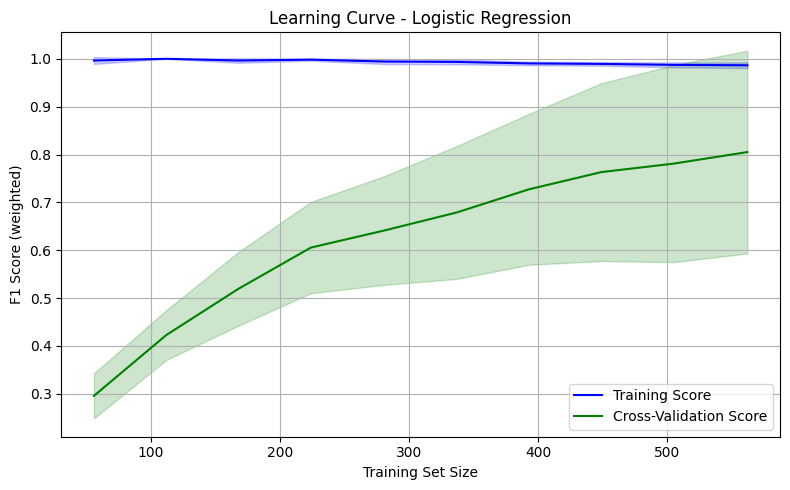

In [40]:
# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=LogisticRegression(max_iter=1000),
    X=tfidf.transform(X),  # Full feature matrix
    y=y,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')
plt.title('Learning Curve - Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score (weighted)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


### ⚠️ Interpretation
#### 🔵 Overfitting is likely happening:

Training score is near-perfect.

Validation score is significantly lower and still rising — suggesting the model is memorizing the training data and not generalizing well early on.

The gap between training and validation scores indicates overfitting, especially at smaller training sizes.

#### ✅ Improvement trend:

As more data is added, validation score improves.

The gap narrows a bit at the end — that’s a good sign. With more data or regularization, this model may generalize even better.

# Multinomial Naive Bayes Model

In [41]:

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)


In [42]:
# Evaluate performance
report_dict_nb = classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_)
print("Multinomial Naive Bayes Classification Report:\n")
print(report_dict_nb)


Multinomial Naive Bayes Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.59      0.70        51
     Neutral       0.84      0.57      0.68        46
    Positive       0.55      0.93      0.69        44

    accuracy                           0.69       141
   macro avg       0.75      0.70      0.69       141
weighted avg       0.75      0.69      0.69       141



### ✅ **Overall Accuracy**

* **69% accuracy**
  → The model correctly predicted sentiment for 69% of the test headlines.

---

### 📊 **Class-wise Analysis**

| Class        | Precision | Recall | F1-score | Notes                                                                                                  |
| ------------ | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------------ |
| **Negative** | 0.86      | 0.59   | 0.70     | Very high precision (few false positives), but recall is low (misses many actual negatives).           |
| **Neutral**  | 0.84      | 0.57   | 0.68     | Similar pattern: good precision, weak recall. Neutral headlines are often misclassified.               |
| **Positive** | 0.55      | 0.93   | 0.69     | Opposite trend: low precision, very high recall — model labels many samples as positive, even wrongly. |

---

### 📉 **Macro and Weighted Averages**

* **Macro Avg F1-score = 0.69**
  → Balanced view across all classes — shows moderate performance.

* **Weighted Avg F1-score = 0.69**
  → Takes class imbalance into account — similar result.

---

### 🧠 **Insights**

* The model is **very confident** when it predicts “Negative” or “Neutral”, but it tends to **over-predict “Positive”**, even when incorrect.
* This leads to **low precision** for “Positive”, but **high recall** — useful if missing actual positives is more costly than misclassifying others as positive.

---

### 🔧 What You Could Try Next

* **Tuning class priors** in Naive Bayes
* **Adjusting decision threshold** if needed
* **Try SVM** — often balances precision and recall better across all classes

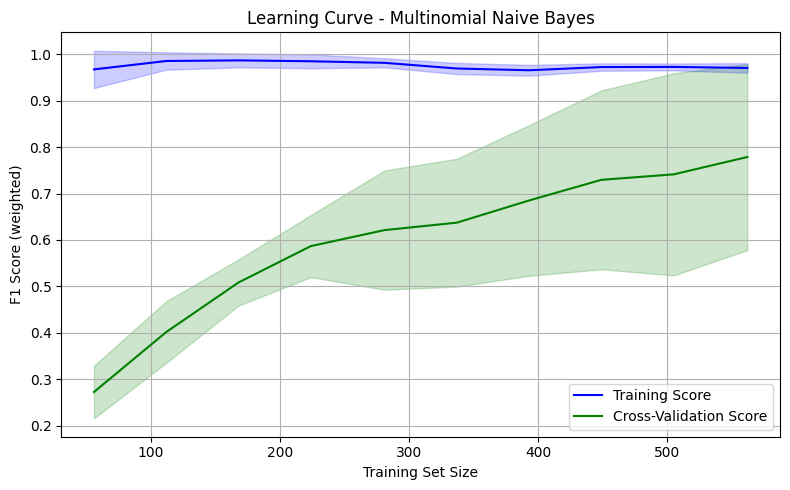

In [43]:
# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=MultinomialNB(),
    X=tfidf.transform(X),
    y=y,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')
plt.title('Learning Curve - Multinomial Naive Bayes')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score (weighted)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


### 🔎 Interpretation
#### ✅ Strengths:
Fast learner: Naive Bayes shows rapid improvement in validation performance with more data.

Good generalization trend: Validation scores improve smoothly and show no major instability.

#### ⚠️ Weaknesses:
Overfitting tendency:

Large gap between training and validation scores, especially at lower training sizes.

The model memorizes training data easily but doesn’t generalize as well early on.

#### 📈 Current status:
The final cross-validation F1 ~0.78 is strong, especially for a simple model like Naive Bayes.

There's still room to reduce the gap by:

Improving data balance

Removing noisy features

Or using a regularized model like SVM

# Support Vector Machine Model

In [44]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train SVM model
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)


In [45]:

# Evaluate performance
report_dict_svm = classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_)
print("Support Vector Machine (SVM) Classification Report:\n")
print(report_dict_svm)

Support Vector Machine (SVM) Classification Report:

              precision    recall  f1-score   support

    Negative       0.92      0.65      0.76        51
     Neutral       0.70      0.87      0.78        46
    Positive       0.77      0.84      0.80        44

    accuracy                           0.78       141
   macro avg       0.80      0.79      0.78       141
weighted avg       0.80      0.78      0.78       141



### ✅ **Overall Accuracy**

* **78% accuracy**
  → The SVM model correctly predicted the sentiment for **78%** of the test headlines — better than both Logistic Regression (75%) and Naive Bayes (69%).

---

### 📊 **Class-wise Breakdown**

| Class        | Precision | Recall | F1-score | Interpretation                                                                                                    |
| ------------ | --------- | ------ | -------- | ----------------------------------------------------------------------------------------------------------------- |
| **Negative** | 0.92      | 0.65   | 0.76     | Very high precision → model rarely mislabels others as negative. But lower recall → misses some actual negatives. |
| **Neutral**  | 0.70      | 0.87   | 0.78     | High recall → detects most neutral headlines. Slightly lower precision → a few false positives.                   |
| **Positive** | 0.77      | 0.84   | 0.80     | Balanced and strong performance — both precision and recall are high.                                             |

---

### 📈 **Averages**

* **Macro Avg F1 = 0.78** → Balanced performance across all classes.
* **Weighted Avg F1 = 0.78** → Similar, confirming consistent performance despite any class imbalance.

---

### 🧠 **Conclusion**

* SVM shows the **best balance between precision and recall** so far.
* Especially good at:

  * Avoiding false positives for "Negative"
  * Detecting most "Neutral" and "Positive" sentiments
* Could still improve **Negative recall** slightly.

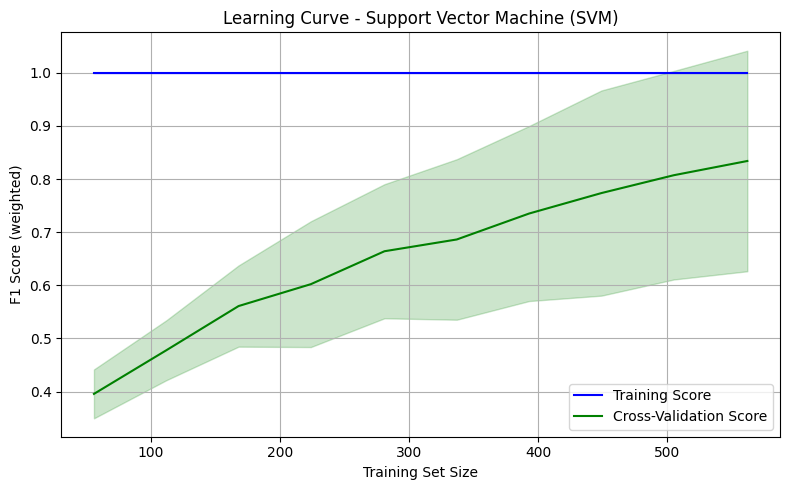

In [46]:

# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=LinearSVC(),
    X=tfidf.transform(X),
    y=y,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')
plt.title('Learning Curve - Support Vector Machine (SVM)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score (weighted)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

### 🔎 **Interpretation**
| Metric                   | Interpretation                                                                         |
| ------------------------ | -------------------------------------------------------------------------------------- |
| 🔵 **Training Score**    | Flat and perfect = strong indicator of **overfitting**. Model memorizes training data. |
| 🟢 **Validation Score**  | Rises smoothly = the model **benefits from more data**. Learning is still ongoing.     |
| ⚠ **Gap between curves** | There’s a visible gap, but it **narrows as data increases**, which is a good sign.     |


# XGBoost Model

In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train XGBoost model
xgb_model = XGBClassifier(eval_metric='mlogloss')
xgb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_tfidf)


In [48]:
# Evaluate performance
report_dict_xgb = classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_)
print("XGBoost Classification Report:\n")
print(report_dict_xgb)


XGBoost Classification Report:

              precision    recall  f1-score   support

    Negative       0.85      0.67      0.75        51
     Neutral       0.65      0.76      0.70        46
    Positive       0.74      0.80      0.77        44

    accuracy                           0.74       141
   macro avg       0.75      0.74      0.74       141
weighted avg       0.75      0.74      0.74       141



### ✅ **Overall Accuracy**

* **74% accuracy**
  → The model predicted sentiments correctly for 74% of the test data — slightly below SVM (78%) and Logistic Regression (75%), but above Naive Bayes (69%).

---

### 📊 **Class-wise Breakdown**

| Class        | Precision | Recall | F1-score | Interpretation                                                                                     |
| ------------ | --------- | ------ | -------- | -------------------------------------------------------------------------------------------------- |
| **Negative** | 0.85      | 0.67   | 0.75     | Very high precision → model avoids false negatives. Lower recall → misses some actual negatives.   |
| **Neutral**  | 0.65      | 0.76   | 0.70     | Moderate performance, favors recall → identifies most neutral items, with some misclassifications. |
| **Positive** | 0.74      | 0.80   | 0.77     | Strong performance — high recall and good precision. Best-handled class in this model.             |

---

### 📈 **Averages**

* **Macro Avg F1 = 0.74** → Balanced across classes.
* **Weighted Avg F1 = 0.74** → Similar score after adjusting for class distribution.

---

### 🧠 **Summary**

* XGBoost shows **balanced but slightly weaker performance** than SVM.
* Handles "Positive" class well, but could improve "Neutral" precision and "Negative" recall.
* Might benefit from hyperparameter tuning (`learning_rate`, `n_estimators`, etc.).


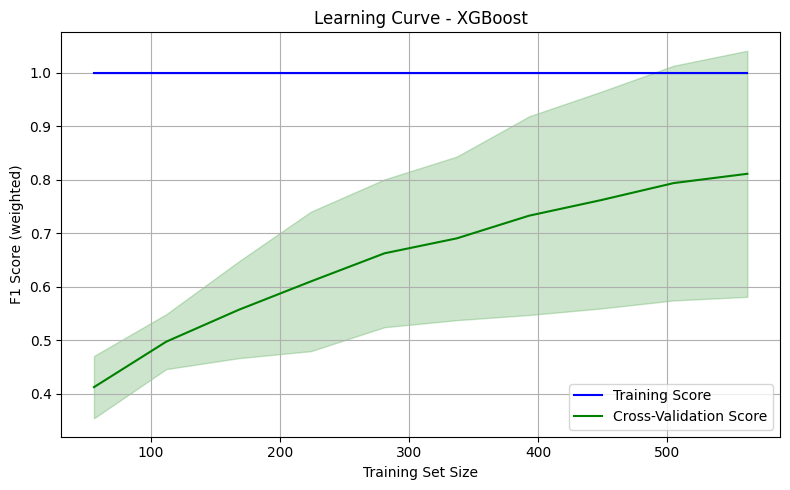

In [49]:
# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=XGBClassifier(eval_metric='mlogloss'),
    X=tfidf.transform(X),
    y=y,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')
plt.title('Learning Curve - XGBoost')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score (weighted)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


### 🔍 Interpretation
| Indicator                      | Meaning                                                                     |
| ------------------------------ | --------------------------------------------------------------------------- |
| **Perfect training score**     | The model is memorizing training data (overfitting).                        |
| **Improving validation curve** | Model **benefits from more data** and shows a strong learning trend.        |
| **Gap between curves**         | Significant but shrinking → model is learning to generalize, albeit slowly. |


# Source /Publisher Influence Analysis

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/processed_news_data.csv")
# Step 1: Filter relevant data (remove rows with missing values)
df_filtered = df.dropna(subset=["source", "sentiments", "engagement"])

# Step 2: Group by source and sentiment, compute average engagement
grouped = df_filtered.groupby(["source", "sentiments"])["engagement"].mean().reset_index()

# Step 3: Pivot table for heatmap or plotting
pivot_table = grouped.pivot(index="source", columns="sentiments", values="engagement").fillna(0)

# Step 4: Sort by average positive or negative engagement
top_positive = pivot_table.sort_values(by="Positive", ascending=False).head(10)
top_negative = pivot_table.sort_values(by="Negative", ascending=False).head(10)


/tmp/ipykernel_18295/358252187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive.reset_index(), x="Positive", y="source", palette="Greens_r")


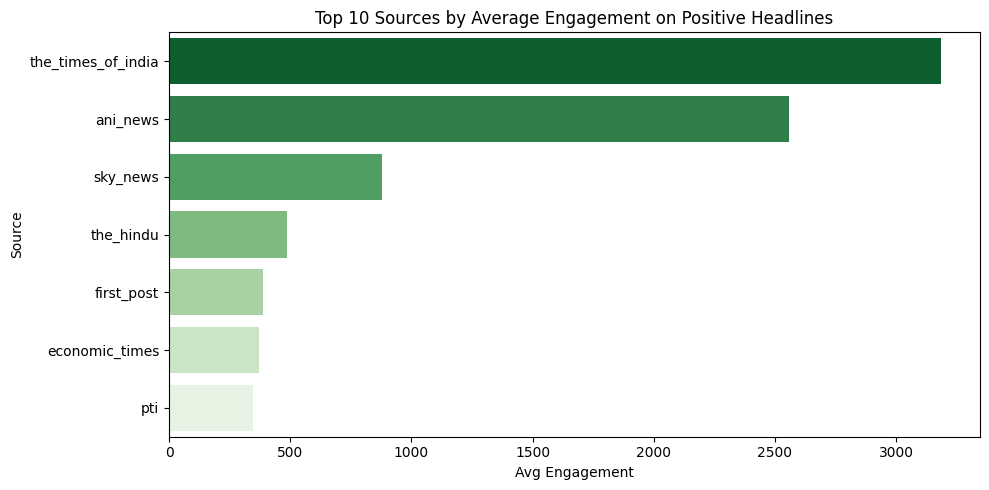

In [51]:

# Plot 1: Top sources by positive sentiment engagement
plt.figure(figsize=(10, 5))
sns.barplot(data=top_positive.reset_index(), x="Positive", y="source", palette="Greens_r")
plt.title("Top 10 Sources by Average Engagement on Positive Headlines")
plt.xlabel("Avg Engagement")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


/tmp/ipykernel_18295/2325738724.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_negative.reset_index(), x="Negative", y="source", palette="Reds_r")


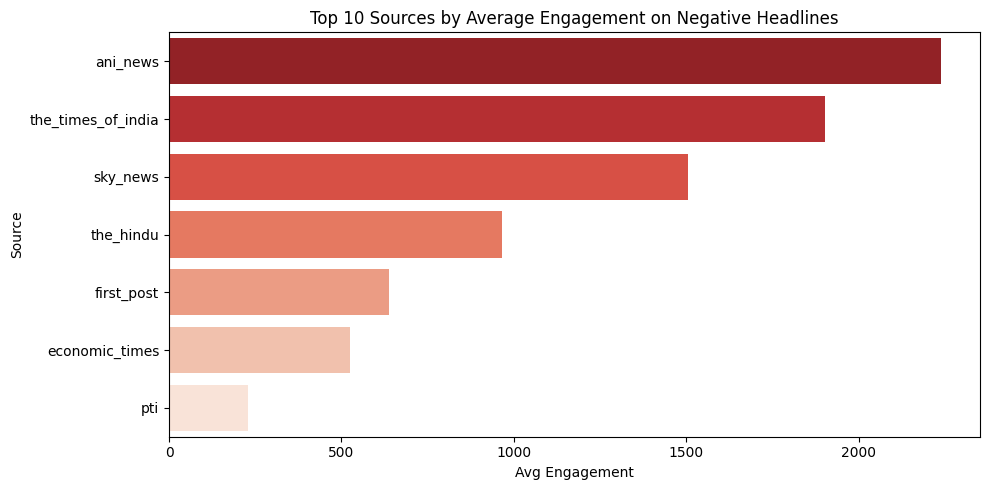

In [52]:

# Plot 2: Top sources by negative sentiment engagement
plt.figure(figsize=(10, 5))
sns.barplot(data=top_negative.reset_index(), x="Negative", y="source", palette="Reds_r")
plt.title("Top 10 Sources by Average Engagement on Negative Headlines")
plt.xlabel("Avg Engagement")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


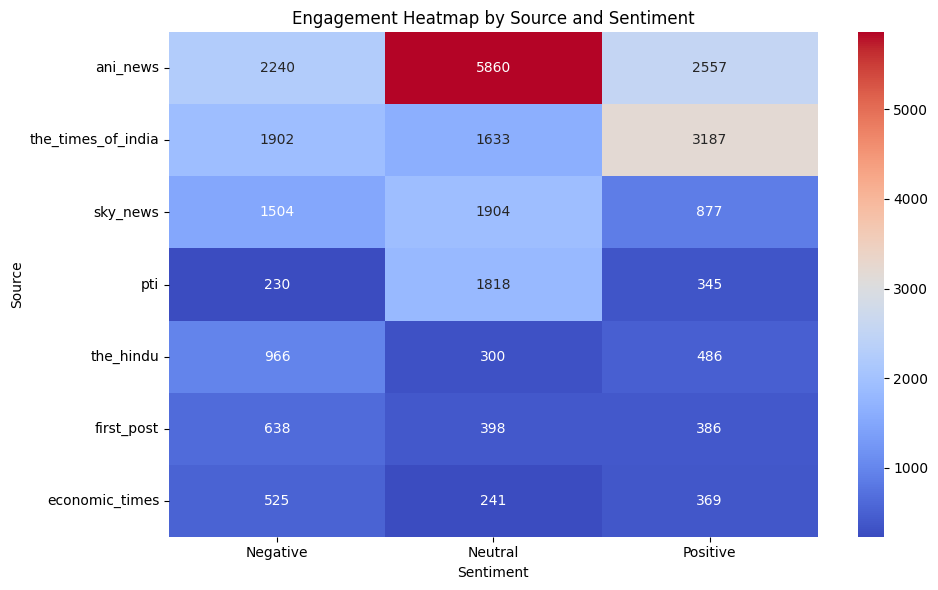

In [55]:

# Heatmap for all sources (top 20)
top_sources = pivot_table.mean(axis=1).sort_values(ascending=False).head(20).index
heatmap_data = pivot_table.loc[top_sources]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".0f")
plt.title("Engagement Heatmap by Source and Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Source")
plt.tight_layout()
plt.show()
